### Librerias

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import seaborn as sns

### Funciones

In [3]:
# =========================
# FFUNCION PARA Ts, Yf y Mp
# =========================
def calcular_metricas(t, y):
    """
    Calcula métricas de la respuesta de un sistema a un escalón.

    Parámetros:
        t (array): vector de tiempos de la respuesta.
        y (array): vector de salida del sistema correspondiente a t.

    Retorna:
        Yf      : valor final de la señal (aproximación al régimen permanente)
        T95     : tiempo en que la señal alcanza el 95% de Yf
        idx_95  : índice correspondiente a T95 en el vector t
        T10     : tiempo en que la señal alcanza el 10% de Yf
        idx_10  : índice correspondiente a T10 en el vector t
        Mp      : sobrepico máximo en porcentaje
        Ts      : tiempo de establecimiento dentro del 5% de Yf
    """
    Yf = y[-1]

    # MÉTRICAS 1er ORDEN
    y_95 = 0.95 * Yf
    y_10 = 0.10 * Yf
    
    idx_95 = np.where(y >= y_95)[0]
    idx_95 = idx_95[0] if len(idx_95) > 0 else None
    T95 = t[idx_95] if idx_95 is not None else None

    idx_10 = np.where(y >= y_10)[0]
    idx_10 = idx_10[0] if len(idx_10) > 0 else None
    T10 = t[idx_10] if idx_10 is not None else None

    # MÉTRICAS 2do ORDEN
    y_max = np.max(y)
    Mp = ((y_max - Yf) / Yf) * 100 if Yf != 0 else 0

    # Tiempo de establecimiento (5%)
    banda = 0.05 * Yf
    Ts = None

    for i in range(len(y)):
        if np.all(np.abs(y[i:] - Yf) <= banda):
            Ts = t[i]
            break

    return Yf, T95, idx_95, T10, idx_10, Mp, Ts


# =========================
# FUNCION PARA GRAFICAR
# =========================
def graficar_respuesta(t_out, y, Yf, T95, idx_95, i, label, color):
    """
    Grafica la respuesta de un sistema y marca el punto T95.

    Parámetros:
        t_out (array): vector de tiempos
        y (array): respuesta del sistema
        Yf (float): valor final de la señal
        T95 (float): tiempo donde se alcanza el 95% de Yf
        idx_95 (int): índice de T95 en t_out
        i (int): índice de la curva (para alternar posición del texto)
        label (str): etiqueta de la curva
        color (str): color de la curva
    """   
    plt.plot(t_out, y, label=label, color=color)
    plt.plot(t_out[idx_95], y[idx_95], 'o', color=color, markersize=5)

    offset_y = -0.04 * Yf
    offset_x = 0.3
    #direction = 1 if i % 2 == 0 else -1

    plt.text(
        t_out[idx_95] + offset_x,
        y[idx_95]  + offset_y,
        f'T95={T95:.2f}s',
        fontsize=12,
        fontfamily='serif',
        fontweight='bold'
    )

def capacitor_comercial(C):
    """
    Ajusta un valor de capacitor teórico a un valor comercial cercano
    usando la serie estándar E12.

    Parámetros:
        C (float): valor teórico del capacitor (F)

    Retorna:
        C_com (float): valor comercial más cercano (F)
    """
    serie = np.array([1.0, 1.2, 1.5, 1.8, 2.2, 2.7, 3.3, 3.9,
                      4.7, 5.6, 6.8, 8.2])
    
    exp = int(np.floor(np.log10(C)))
    base = C / (10**exp)
    
    idx = np.argmin(np.abs(serie - base))
    C_com = serie[idx] * (10**exp)
    
    return C_com

## Circuito RC

###  PARTE 1: LAZO ABIERTO

#### LEER: si quieres podemos cambiar la forma d e la grafica 


===== LAZO ABIERTO =====

--------- τ = 0.47 s ----------
C1 = 47.0 µF || R = 10000 Ω 

Yf = 5.000
T10 ≈ 0.080 s
T95 ≈ 1.441 s

--------- τ = 4.70 s ----------
C1 = 47.0 µF || R = 100000 Ω 

Yf = 4.999
T10 ≈ 0.521 s
T95 ≈ 14.094 s

--------- τ = 8.46 s ----------
C1 = 47.0 µF || R = 180000 Ω 

Yf = 4.956
T10 ≈ 0.921 s
T95 ≈ 24.064 s


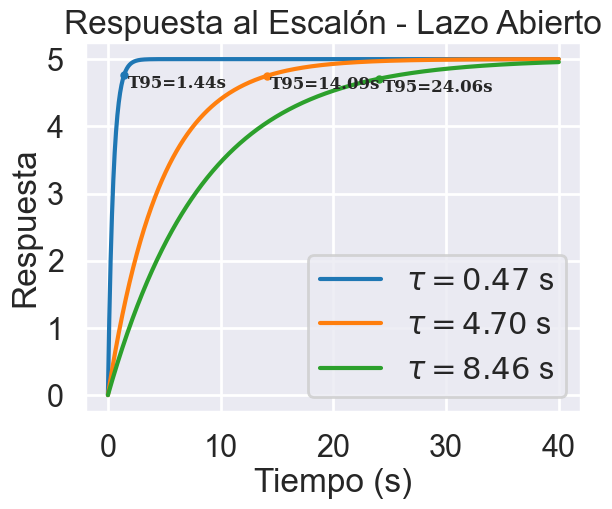

In [4]:
entrada =5

C1 = 47 * 1e-6 #|µF
R1 = 10000 # 10kΩ
tao1 = R1 * C1  # 0.47 s 1 Rango

R2 = 100000 # 100kΩ
tao2 = R2 * C1  # 4.7 s  2 Rango

R3 = 180000 # 180kΩ
tao3 = R3 * C1  # 9.4 s 3 Rango

taos = [tao1, tao2, tao3]
t = np.linspace(0, 40, 1000)


print("\n===== LAZO ABIERTO =====")
plt.figure()
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

sns.set_theme(
    context='poster',
    style='darkgrid',
)

for i, tao in enumerate(taos):

    print(f"\n--------- τ = {tao:.2f} s ----------")
    
    color = colores[i % len(colores)] 
    sistema = ctrl.TransferFunction([1], [tao, 1])
    t_out, y = ctrl.step_response(sistema, t)
    y = y * entrada  # Aplicar la entrada al sistema
    
    Yf, T95, idx_95, T10, idx_10, _, _ = calcular_metricas(t_out, y)

    print(f"C1 = {C1 * 1e6:.1f} µF || R = {tao / C1:.0f} Ω \n")
    print(f"Yf = {Yf:.3f}")
    print(f"T10 ≈ {T10:.3f} s")
    print(f"T95 ≈ {T95:.3f} s")



    graficar_respuesta(t_out, y, Yf, T95, idx_95, i,
                        label=f'$\\tau = {tao:.2f}$ s', color=color)

plt.grid(True)
plt.xlabel('Tiempo (s)')
plt.ylabel('Respuesta')
plt.title('Respuesta al Escalón - Lazo Abierto')
plt.legend()


In [5]:
print("\n===== RESULTADOS =====")
print(f"{'τ (s)':<8}{'Yf':<8}{'T10 (s)':<10}{'y(T10)':<10}{'T95 (s)':<10}{'y(T95)':<10}{'Ts (s)':<10}")

for tao in taos:
    sistema = ctrl.TransferFunction([1], [tao, 1])
    t_out, y = ctrl.step_response(sistema, t)
    
    Yf, T95, idx_95, T10, idx_10, _, _ = calcular_metricas(t_out, y)
    
    Ts = T95 - T10 if (T95 is not None and T10 is not None) else None
    
    y_T10 = y[idx_10] if idx_10 is not None else None
    y_T95 = y[idx_95] if idx_95 is not None else None

    print(f"{tao:<8.2f}{Yf:<8.2f}{T10:<10.2f}{y_T10:<10.2f}{T95:<10.2f}{y_T95:<10.2f}{Ts:<10.2f}")


===== RESULTADOS =====
τ (s)   Yf      T10 (s)   y(T10)    T95 (s)   y(T95)    Ts (s)    
0.47    1.00    0.08      0.16      1.44      0.95      1.36      
4.70    1.00    0.52      0.10      14.09     0.95      13.57     
8.46    0.99    0.92      0.10      24.06     0.94      23.14     


###  PARTE 2: LAZO CERRADO


===== LAZO CERRADO =====

------K = 0.5 || tau = 4.70 s----------
Yf = 1.667
T10 ≈ 0.360 s
T95 ≈ 9.409 s

------K = 2 || tau = 4.70 s----------
Yf = 3.333
T10 ≈ 0.200 s
T95 ≈ 4.725 s

------K = 5 || tau = 4.70 s----------
Yf = 4.167
T10 ≈ 0.120 s
T95 ≈ 2.362 s

------K = 10 || tau = 4.70 s----------
Yf = 4.545
T10 ≈ 0.080 s
T95 ≈ 1.281 s


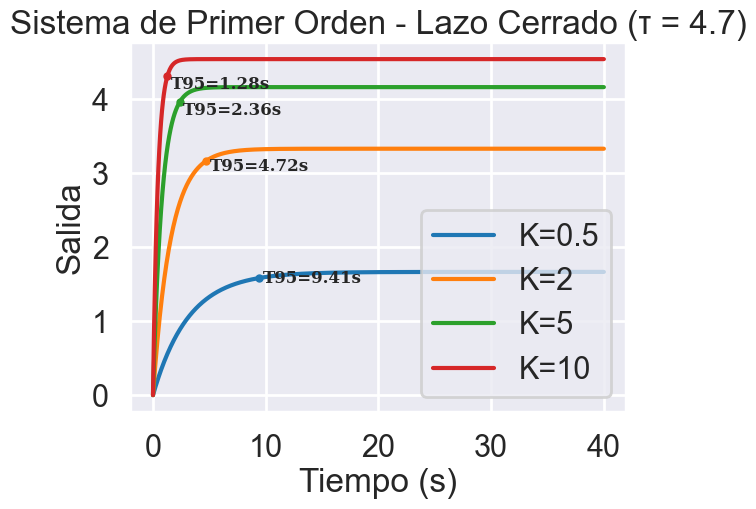

In [6]:
K_values = [0.5, 2, 5, 10]
tau = 4.7
entrada = 5

t = np.linspace(0, 40, 1000)

colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure()
print("\n===== LAZO CERRADO =====")

for i, K in enumerate(K_values):
    
    color = colores[i % len(colores)]

    G = ctrl.TransferFunction([1], [tau, 1])
    sistema_cerrado = ctrl.feedback(K * G, 1)
    
    t_out, y = ctrl.step_response(sistema_cerrado, t)
    y = y * entrada  # Aplicar la entrada al sistema

    Yf, T95, idx_95, T10, idx_10, _, _ = calcular_metricas(t_out, y)
    
    print(f"\n------K = {K} || tau = {tau:.2f} s----------")
    print(f"Yf = {Yf:.3f}")
    print(f"T10 ≈ {T10:.3f} s")
    print(f"T95 ≈ {T95:.3f} s")

    graficar_respuesta(
        t_out, y, Yf, T95, idx_95,
        i,
        label=f'K={K}',
        color=color
    )

plt.title(f"Sistema de Primer Orden - Lazo Cerrado (τ = {tau})")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
plt.legend()
plt.grid(True)
plt.show()

## Sistema RLC


===== CASO 1: ζ  FIJO =====

---------ωn deseado = 176000 || factorAmortiguamiento = 0.02 ----
C comercial = 6.80e-08 F || R = 3.33 Ω 

Yf=4.990, Mp=94.31%, Ts=8.372875e-04s
Frecuencia de entrada recomendada= 220.00 Hz

---------ωn deseado = 200000 || factorAmortiguamiento = 0.02 ----
C comercial = 5.60e-08 F || R = 3.66 Ω 

Yf=4.990, Mp=94.28%, Ts=7.597520e-04s
Frecuencia de entrada recomendada= 250.00 Hz


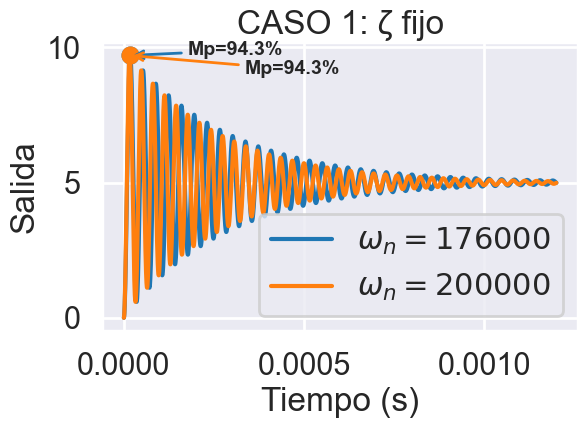

In [10]:
print("\n===== CASO 1: ζ  FIJO =====")

factorA = 0.02
L = 470e-6 #470 µH
wn_values = [176000, 200000]

colores = ['#1f77b4', '#ff7f0e', '#2ca02c']
plt.figure()

for i, wn in enumerate(wn_values):

    color = colores[i % len(colores)]
    # 1. C teórico
    C_teo = 1 / (L * wn**2)
    
    # 2. C comercial
    C = capacitor_comercial(C_teo)
    
    # 3. R ajustado
    R = 2 * factorA * np.sqrt(L / C)
    
    # Sistema
    num = [1]
    den = [L*C, R*C, 1]
    
    tao = 1 / (wn * factorA)
    frecuencia_entrada = 1 / (tao * 16)
    
    sistema = ctrl.TransferFunction(num, den)
    
    t = np.linspace(0, 0.0012, 5000)
    t_out, y = ctrl.step_response(sistema, t)
    y=y*5
    Yf, _, _, _, _, Mp, Ts = calcular_metricas(t_out, y)
    
    print(f"\n---------ωn deseado = {wn} || factorAmortiguamiento = {factorA} ----")
    print(f"C comercial = {C:.2e} F || R = {R:.2f} Ω \n")
    print(f"Yf={Yf:.3f}, Mp={Mp:.2f}%, Ts={Ts:.6e}s")
    print(f'Frecuencia de entrada recomendada= {frecuencia_entrada:.2f} Hz')
    
    plt.plot(
        t_out, y,
        label=f'$\\omega_n={wn}$',
        color=color
    )

    if Mp is not None:
        idx_mp = np.argmax(y)
        
        x_mp = t_out[idx_mp]
        y_mp = y[idx_mp]

        plt.plot(x_mp, y_mp, 'o', color=color)
        plt.annotate(
            f'Mp={Mp:.1f}%',
            xy=(x_mp, y_mp),
            xytext=(x_mp + 0.00016*(i+1), y_mp - 0.7*(i)),
            arrowprops=dict(arrowstyle='->', color=color),
            fontsize=14,
            fontweight='bold'
        )
        

plt.title("CASO 1: ζ fijo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
plt.legend()
plt.tight_layout()
plt.show()

### CASO 2: ωn FIJO


===== CASO 2: ωn FIJO =====

--------ζ = 0.02 | ωn = 176000 rad/s ---------
R = 3.33 Ω || C = 68.00 nF|| l = 470.00 µH
  
Yf = 4.995
Mp = 94.02%
Ts = 8.374187e-04 s

--------ζ = 1.2 | ωn = 176000 rad/s ---------
R = 199.53 Ω || C = 68.00 nF|| l = 470.00 µH
  
Yf = 5.000
Mp = 0.00%
Ts = 3.526763e-05 s


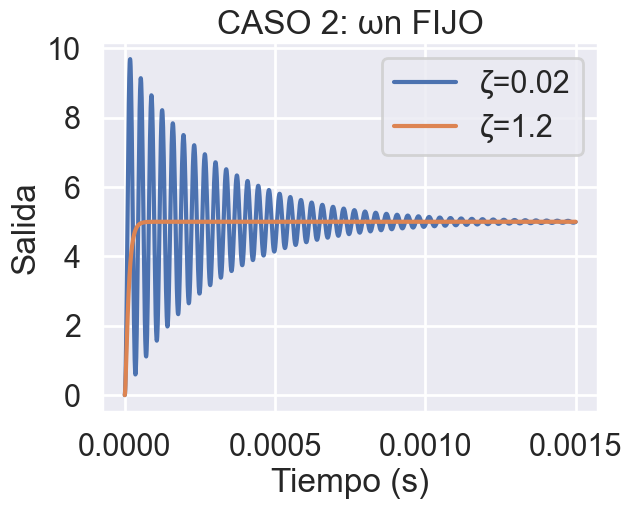

In [8]:
print("\n===== CASO 2: ωn FIJO =====")

wn = 176000
entrada = 5

# 1. C teórico
C_teo = 1 / (L * wn**2)

# 2. C comercial
C = capacitor_comercial(C_teo)
factorA = [0.02, 1.2]

plt.figure()

for fA in factorA:
    
    # 3. Recalcular R con C real
    R = 2 * fA * np.sqrt(L/C)
    
    num = [1]
    den = [L*C, R*C, 1]
    
    sistema = ctrl.TransferFunction(num, den)

    t = np.linspace(0, 0.0015, 2000)
    t_out, y = ctrl.step_response(sistema, t)
    y *= entrada
    
    Yf, _, _, _, _, Mp, Ts = calcular_metricas(t_out, y)
    
    tao= 1/(wn*fA)

    print(f"\n--------ζ = {fA} | ωn = {wn} rad/s ---------")
    print(f"R = {R:.2f} Ω || C = {C*1e9:.2f} nF|| l = {L*1e6:.2f} µH\n  ")
    print(f"Yf = {Yf:.3f}")
    print(f"Mp = {Mp:.2f}%")
    print(f"Ts = {Ts:.6e} s")
    
    plt.plot(t_out, y, label=f"ζ={fA}")

plt.title("CASO 2: ωn FIJO")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
plt.legend()
plt.grid(True)